In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Untitled folder', 'FB_IMG_1543403511011.jpg', 'IMG_20190309_112233.jpg', 'IMG_20190309_103223.jpg', 'IMG_20190309_112258.jpg', 'IMG_20190309_093019.jpg', 'IMG_20190309_093018.jpg', 'IMG_20190309_093009.jpg', 'IMG_20190309_092806.jpg', 'IMG_20190309_092802.jpg', 'IMG_20190309_092759.jpg', 'IMG_20190309_090807.jpg', 'IMG_20190309_090135.jpg', 'IMG_20190309_090149.jpg', 'IMG_20190308_221859.jpg', 'IMG_20190308_221745.jpg', 'IMG_20190309_090120.jpg', 'VID_20190309_103311.mp4', '15957.jpg', 'received_110151857098682.jpeg', 'Project_08-11(2)_HD 720p.mp4', 'VID_20190309_101854.mp4', 'khan saheb.gsite', 'Project_10-21(3)_Full HD 1080p.mp4', 'Project_12-05_HD 720p_(1).mp4', ' দৃশ্য-১.gdoc', 'Re_Improvement Grade Sheet_Format FSIT__Theory.xls', 'Untitled spreadsheet (3).gsheet', 'Tutorial_list.gsheet', "ChittaGong - Cox's Bazar.gmap", 'CV__lastest___FWdsJJV.pdf', 'Md. Siam_Khan_Portfolio', 'Last official cv (1).pdf', 'Last official cv.pdf', 'Untitled spreadsheet (2).gsheet',

In [ ]:
import subprocess
result = subprocess.run(['find', '/content/drive', '-name', 'YOLO', '-type', 'd'],
                      capture_output=True, text=True)
print(result.stdout)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
['Colab Notebooks', 'Untitled folder', 'FB_IMG_1543403511011.jpg', 'IMG_20190309_112233.jpg', 'IMG_20190309_103223.jpg', 'IMG_20190309_112258.jpg', 'IMG_20190309_093019.jpg', 'IMG_20190309_093018.jpg', 'IMG_20190309_093009.jpg', 'IMG_20190309_092806.jpg', 'IMG_20190309_092802.jpg', 'IMG_20190309_092759.jpg', 'IMG_20190309_090807.jpg', 'IMG_20190309_090135.jpg', 'IMG_20190309_090149.jpg', 'IMG_20190308_221859.jpg', 'IMG_20190308_221745.jpg', 'IMG_20190309_090120.jpg', 'VID_20190309_103311.mp4', '15957.jpg', 'received_110151857098682.jpeg', 'Project_08-11(2)_HD 720p.mp4', 'VID_20190309_101854.mp4', 'khan saheb.gsite', 'Project_10-21(3)_Full HD 1080p.mp4', 'Project_12-05_HD 720p_(1).mp4', ' দৃশ্য-১.gdoc', 'Re_Improvement Grade Sheet_Format FSIT__Theory.xls', 'Untitled spreadsheet (3).gsheet', 'Tutorial_list.gsheet', "ChittaGong - Cox's Bazar.gmap", 'CV__lastest___FWdsJJV.pdf', 'Md. Siam_Khan_Portfolio', 'Last official cv (1).pdf', 'Last official cv.pdf', 'Untitle

In [ ]:
import shutil
shutil.copytree('/content/drive/MyDrive/YOLO/data', '/content/poultry_data')
print("✅ Done!")

✅ Done!


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json, os
import torchvision.transforms as T

class PoultryCOCO(Dataset):
    def __init__(self, img_dir, ann_file):
        self.img_dir = img_dir
        with open(ann_file) as f:
            coco = json.load(f)
        self.imgs = {img['id']: img for img in coco['images']}
        self.anns = {}
        for ann in coco['annotations']:
            iid = ann['image_id']
            self.anns.setdefault(iid, []).append(ann)
        self.ids = list(self.imgs.keys())

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        iid = self.ids[idx]
        img_info = self.imgs[iid]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')
        anns = self.anns.get(iid, [])
        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann['bbox']
            x1, y1, x2, y2 = x, y, x+w, y+h
            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(ann['category_id'])
        if boxes:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([iid])
        }
        img = T.ToTensor()(img)
        return img, target

base = '/content/poultry_data'

train_ds = PoultryCOCO(f'{base}/train/images', f'{base}/train_coco.json')
val_ds   = PoultryCOCO(f'{base}/val/images',   f'{base}/val_coco.json')

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                          num_workers=2, pin_memory=True,
                          collate_fn=lambda x: tuple(zip(*x)))
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False,
                          num_workers=2, pin_memory=True,
                          collate_fn=lambda x: tuple(zip(*x)))

device = torch.device('cuda')
print(f"Using: {device}")

model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 5)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("✅ Training শুরু হচ্ছে...")

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for imgs, targets in train_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        losses = sum(loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        total_loss += losses.item()
    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

    # প্রতি epoch এ Drive এ save
    torch.save(model.state_dict(),
        f'/content/drive/MyDrive/YOLO/output/faster_rcnn_epoch{epoch+1}.pth')
    print(f"✅ Saved to Drive!")

print("🎉 Training complete!")

Using: cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 168MB/s]


✅ Training শুরু হচ্ছে...
Epoch [1/20] Loss: 0.2385
✅ Saved to Drive!
Epoch [2/20] Loss: 0.1638
✅ Saved to Drive!
Epoch [3/20] Loss: 0.1438
✅ Saved to Drive!
Epoch [4/20] Loss: 0.1275
✅ Saved to Drive!
Epoch [5/20] Loss: 0.1160
✅ Saved to Drive!
Epoch [6/20] Loss: 0.0933
✅ Saved to Drive!


KeyboardInterrupt: 

In [ ]:
import torch

# ================================
# Model, Optimizer, Scheduler আবার তৈরি করো
# ================================
device = torch.device('cuda')
model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 5)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# ================================
# পুরনো checkpoint (epoch 6) লোড করো
# ================================
old_checkpoint_path = '/content/drive/MyDrive/YOLO/output/faster_rcnn_epoch6.pth'
model.load_state_dict(torch.load(old_checkpoint_path))
model.to(device)

start_epoch = 6  # epoch 6 পর্যন্ত হয়ে গেছে, তাই 7 নম্বর (index 6) থেকে শুরু
num_epochs = 20

print(f"✅ Epoch {start_epoch} পর্যন্ত checkpoint লোড হয়েছে। এখন থেকে resume হচ্ছে...")

# ================================
# Training loop (নতুন checkpoint ফরম্যাট সহ)
# ================================
for epoch in range(start_epoch, num_epochs):
    model.train()
    total_loss = 0
    for imgs, targets in train_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        losses = sum(loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        total_loss += losses.item()
    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

    checkpoint_path = f'/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch{epoch+1}.pth'
    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'epoch': epoch
    }, checkpoint_path)
    print(f"✅ Full checkpoint saved to Drive!")

print("🎉 Training complete!")

✅ Epoch 6 পর্যন্ত checkpoint লোড হয়েছে। এখন থেকে resume হচ্ছে...
Epoch [7/20] Loss: 0.1007
✅ Full checkpoint saved to Drive!
Epoch [8/20] Loss: 0.0951
✅ Full checkpoint saved to Drive!
Epoch [9/20] Loss: 0.0875
✅ Full checkpoint saved to Drive!
Epoch [10/20] Loss: 0.0790
✅ Full checkpoint saved to Drive!
Epoch [11/20] Loss: 0.0734
✅ Full checkpoint saved to Drive!
Epoch [12/20] Loss: 0.0571
✅ Full checkpoint saved to Drive!
Epoch [13/20] Loss: 0.0509
✅ Full checkpoint saved to Drive!
Epoch [14/20] Loss: 0.0480
✅ Full checkpoint saved to Drive!
Epoch [15/20] Loss: 0.0450
✅ Full checkpoint saved to Drive!
Epoch [16/20] Loss: 0.0433
✅ Full checkpoint saved to Drive!
Epoch [17/20] Loss: 0.0410
✅ Full checkpoint saved to Drive!
Epoch [18/20] Loss: 0.0406
✅ Full checkpoint saved to Drive!


KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch18.pth')
print(type(checkpoint))
print(checkpoint.keys() if isinstance(checkpoint, dict) else "এটা raw state_dict")

<class 'dict'>
dict_keys(['model', 'optimizer', 'scheduler', 'epoch'])


In [ ]:
print(train_loader)

In [ ]:
print(time.time())

1782990817.3584921


In [ ]:
import time

In [ ]:
device = torch.device('cuda')
model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 5)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

checkpoint_path = '/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch18.pth'
checkpoint = torch.load(checkpoint_path)

model.load_state_dict(checkpoint['model'])
optimizer.load_state_dict(checkpoint['optimizer'])
scheduler.load_state_dict(checkpoint['scheduler'])
model.to(device)

start_epoch = checkpoint['epoch'] + 1
num_epochs = 20

print(f"✅ Epoch {checkpoint['epoch']+1} পর্যন্ত checkpoint লোড হয়েছে। এখন resume হচ্ছে...")

for epoch in range(start_epoch, num_epochs):
    epoch_start = time.time()
    model.train()
    total_loss = 0
    for imgs, targets in train_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        losses = sum(loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        total_loss += losses.item()
    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f} | সময়: {epoch_time:.1f}s")

    save_path = f'/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch{epoch+1}.pth'
    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'epoch': epoch
    }, save_path)
    print(f"✅ Full checkpoint saved to Drive!")

print("🎉 Training complete!")

✅ Epoch 18 পর্যন্ত checkpoint লোড হয়েছে। এখন resume হচ্ছে...
Epoch [19/20] Loss: 0.0406 | সময়: 555.8s
✅ Full checkpoint saved to Drive!
Epoch [20/20] Loss: 0.0403 | সময়: 545.2s
✅ Full checkpoint saved to Drive!
🎉 Training complete!


In [ ]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.5 MB/s eta 0:00:00


In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import time

model.eval()
metric = MeanAveragePrecision(iou_type="bbox")

total_time = 0
num_images = 0

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = [img.to(device) for img in imgs]

        start = time.time()
        preds = model(imgs)
        total_time += time.time() - start
        num_images += len(imgs)

        preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]

        metric.update(preds, targets_cpu)

results = metric.compute()

print("📊 Faster R-CNN Evaluation Results")
print(f"mAP@0.5:0.95 : {results['map'].item():.4f}")
print(f"mAP@0.5      : {results['map_50'].item():.4f}")
print(f"mAP@0.75     : {results['map_75'].item():.4f}")
print(f"Mean Recall  : {results['mar_100'].item():.4f}")
print(f"⏱️ Avg inference time per image: {total_time/num_images*1000:.2f} ms")
print(f"⚡ FPS: {num_images/total_time:.2f}")

📊 Faster R-CNN Evaluation Results
mAP@0.5:0.95 : 0.4235
mAP@0.5      : 0.8459
mAP@0.75     : 0.3138
Mean Recall  : 0.5064
⏱️ Avg inference time per image: 201.44 ms
⚡ FPS: 4.96


In [ ]:
import torch
from torchvision.ops import box_iou

def compute_precision_recall(model, val_loader, device, conf_threshold=0.5, iou_threshold=0.5):
    model.eval()
    total_tp, total_fp, total_fn = 0, 0, 0

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = [img.to(device) for img in imgs]
            preds = model(imgs)

            for pred, target in zip(preds, targets):
                # confidence threshold অনুযায়ী filter করো
                keep = pred['scores'] >= conf_threshold
                pred_boxes = pred['boxes'][keep].cpu()
                pred_labels = pred['labels'][keep].cpu()

                gt_boxes = target['boxes']
                gt_labels = target['labels']

                if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                    continue
                if len(pred_boxes) == 0:
                    total_fn += len(gt_boxes)
                    continue
                if len(gt_boxes) == 0:
                    total_fp += len(pred_boxes)
                    continue

                ious = box_iou(pred_boxes, gt_boxes)
                matched_gt = set()
                tp = 0

                for i in range(len(pred_boxes)):
                    best_iou, best_j = 0, -1
                    for j in range(len(gt_boxes)):
                        if j in matched_gt:
                            continue
                        if pred_labels[i] == gt_labels[j] and ious[i, j] > best_iou:
                            best_iou = ious[i, j]
                            best_j = j
                    if best_iou >= iou_threshold:
                        tp += 1
                        matched_gt.add(best_j)

                fp = len(pred_boxes) - tp
                fn = len(gt_boxes) - len(matched_gt)

                total_tp += tp
                total_fp += fp
                total_fn += fn

    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    return precision, recall, f1

precision, recall, f1 = compute_precision_recall(model, val_loader, device)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Precision: 0.7899
Recall: 0.8664
F1-score: 0.8264


In [ ]:
import json

with open('/content/poultry_data/train/train_coco.json') as f:
    coco = json.load(f)

for cat in coco['categories']:
    print(cat['id'], cat['name'])

FileNotFoundError: [Errno 2] No such file or directory: '/content/poultry_data/train/train_coco.json'

In [ ]:
!find / -name "*coco*.json" 2>/dev/null

/content/poultry_data/test_coco.json
/content/poultry_data/train_coco.json
/content/poultry_data/val_coco.json
/content/drive/.shortcut-targets-by-id/1Mmy0jMN7W3TVrlYIPvh4rutwhW6PuIzU/YOLO/data/train_coco.json
/content/drive/.shortcut-targets-by-id/1Mmy0jMN7W3TVrlYIPvh4rutwhW6PuIzU/YOLO/data/val_coco.json
/content/drive/.shortcut-targets-by-id/1Mmy0jMN7W3TVrlYIPvh4rutwhW6PuIzU/YOLO/data/test_coco.json


In [ ]:
import json

with open('/content/poultry_data/train_coco.json') as f:
    coco = json.load(f)

for cat in coco['categories']:
    print(cat['id'], cat['name'])

1 cocci
2 healthy
3 ncd
4 salmo


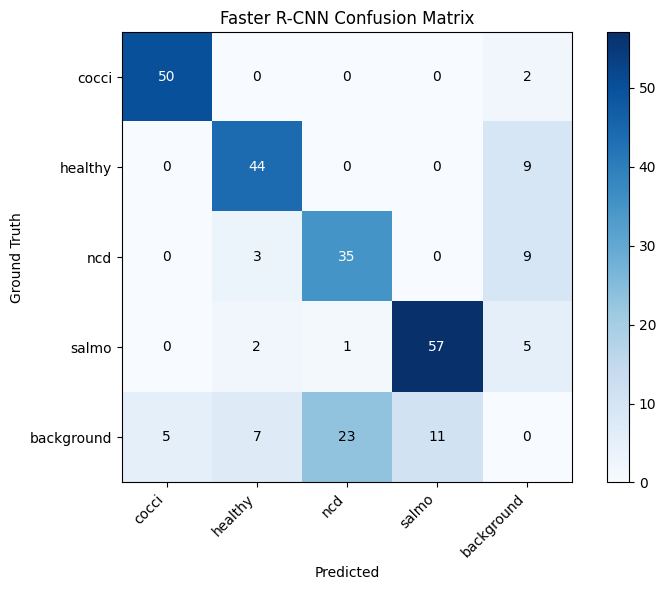

✅ Confusion matrix saved to Drive!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.ops import box_iou

class_names = ['cocci', 'healthy', 'ncd', 'salmo']  # id 1,2,3,4 অনুযায়ী ✅ কনফার্মড
num_classes = len(class_names)

conf_matrix = np.zeros((num_classes + 1, num_classes + 1), dtype=int)
bg_idx = num_classes

model.eval()
conf_threshold = 0.5
iou_threshold = 0.5

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = [img.to(device) for img in imgs]
        preds = model(imgs)

        for pred, target in zip(preds, targets):
            keep = pred['scores'] >= conf_threshold
            pred_boxes = pred['boxes'][keep].cpu()
            pred_labels = pred['labels'][keep].cpu()

            gt_boxes = target['boxes']
            gt_labels = target['labels']

            matched_pred = set()
            matched_gt = set()

            if len(gt_boxes) > 0 and len(pred_boxes) > 0:
                ious = box_iou(pred_boxes, gt_boxes)
                for i in range(len(pred_boxes)):
                    best_iou, best_j = 0, -1
                    for j in range(len(gt_boxes)):
                        if j in matched_gt:
                            continue
                        if ious[i, j] > best_iou:
                            best_iou = ious[i, j]
                            best_j = j
                    if best_iou >= iou_threshold:
                        gt_class = gt_labels[best_j].item() - 1
                        pred_class = pred_labels[i].item() - 1
                        conf_matrix[gt_class, pred_class] += 1
                        matched_gt.add(best_j)
                        matched_pred.add(i)

            for i in range(len(pred_boxes)):
                if i not in matched_pred:
                    pred_class = pred_labels[i].item() - 1
                    conf_matrix[bg_idx, pred_class] += 1

            for j in range(len(gt_boxes)):
                if j not in matched_gt:
                    gt_class = gt_labels[j].item() - 1
                    conf_matrix[gt_class, bg_idx] += 1

labels_with_bg = class_names + ['background']
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(conf_matrix, cmap='Blues')

ax.set_xticks(range(len(labels_with_bg)))
ax.set_yticks(range(len(labels_with_bg)))
ax.set_xticklabels(labels_with_bg, rotation=45, ha='right')
ax.set_yticklabels(labels_with_bg)
ax.set_xlabel('Predicted')
ax.set_ylabel('Ground Truth')
ax.set_title('Faster R-CNN Confusion Matrix')

for i in range(len(labels_with_bg)):
    for j in range(len(labels_with_bg)):
        ax.text(j, i, conf_matrix[i, j], ha='center', va='center',
                 color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/YOLO/output/faster_rcnn_confusion_matrix.png', dpi=300)
plt.show()

print("✅ Confusion matrix saved to Drive!")

In [ ]:
# Faster R-CNN inference time measuring
import time

model.eval()
start = time.time()
# test set এ run
end = time.time()

fps = len(test_dataset) / (end - start)
print(f"Faster R-CNN FPS: {fps:.2f}")

NameError: name 'model' is not defined

In [ ]:
import time
import torch

model.eval()

total_time = 0
num_images = 0

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]

        start = time.time()
        outputs = model(images)
        end = time.time()

        total_time += (end - start)
        num_images += len(images)

fps = num_images / total_time
avg_time_ms = (total_time / num_images) * 1000

print(f"Total images tested: {num_images}")
print(f"Total time: {total_time:.2f} seconds")
print(f"Average inference time: {avg_time_ms:.2f} ms per image")
print(f"FPS: {fps:.2f}")

NameError: name 'model' is not defined

In [ ]:
import os

# YOLO folder এ সব files দেখো
for root, dirs, files in os.walk('/content/drive/MyDrive/YOLO'):
    for file in files:
        if file.endswith('.pth'):
            print(os.path.join(root, file))

/content/drive/MyDrive/YOLO/output/faster_rcnn_epoch1.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_epoch2.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_epoch3.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_epoch4.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_epoch5.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_epoch6.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch7.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch8.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch9.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch10.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch11.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch12.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch13.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch14.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch15.pth
/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch16.pth
/content/drive/

In [ ]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Model বানাও
num_classes = 5  # 4 class + background
model = fasterrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Epoch 20 load করো
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch20.pth',
    map_location=device
))

model.to(device)
model.eval()
print("✅ Model loaded successfully!")

Device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


RuntimeError: Error(s) in loading state_dict for FasterRCNN:
	Missing key(s) in state_dict: "backbone.body.conv1.weight", "backbone.body.bn1.weight", "backbone.body.bn1.bias", "backbone.body.bn1.running_mean", "backbone.body.bn1.running_var", "backbone.body.layer1.0.conv1.weight", "backbone.body.layer1.0.bn1.weight", "backbone.body.layer1.0.bn1.bias", "backbone.body.layer1.0.bn1.running_mean", "backbone.body.layer1.0.bn1.running_var", "backbone.body.layer1.0.conv2.weight", "backbone.body.layer1.0.bn2.weight", "backbone.body.layer1.0.bn2.bias", "backbone.body.layer1.0.bn2.running_mean", "backbone.body.layer1.0.bn2.running_var", "backbone.body.layer1.0.conv3.weight", "backbone.body.layer1.0.bn3.weight", "backbone.body.layer1.0.bn3.bias", "backbone.body.layer1.0.bn3.running_mean", "backbone.body.layer1.0.bn3.running_var", "backbone.body.layer1.0.downsample.0.weight", "backbone.body.layer1.0.downsample.1.weight", "backbone.body.layer1.0.downsample.1.bias", "backbone.body.layer1.0.downsampl

In [ ]:
# Checkpoint load করো
checkpoint = torch.load(
    '/content/drive/MyDrive/YOLO/output/faster_rcnn_full_epoch20.pth',
    map_location=device
)

# Checkpoint এর ভেতর থেকে শুধু model weights নাও
model.load_state_dict(checkpoint['model'])

model.to(device)
model.eval()
print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [ ]:
import time
from torch.utils.data import DataLoader

# Test loader দরকার — আগে dataset বানাও
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir):
        self.img_dir = img_dir
        self.imgs = [f for f in os.listdir(img_dir)
                     if f.endswith(('.jpg', '.jpeg', '.png'))]
        self.transforms = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        from PIL import Image
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        img = Image.open(img_path).convert('RGB')
        return self.transforms(img)

import os
test_dataset = TestDataset('/content/drive/MyDrive/YOLO/data/test/images')
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# FPS measure করো
total_time = 0
num_images = 0

with torch.no_grad():
    for images in test_loader:
        images = [img.to(device) for img in images]

        start = time.time()
        outputs = model(images)
        end = time.time()

        total_time += (end - start)
        num_images += 1

fps = num_images / total_time
avg_ms = (total_time / num_images) * 1000

print(f"Total images: {num_images}")
print(f"Average inference time: {avg_ms:.2f} ms/image")
print(f"FPS: {fps:.2f}")

Total images: 131
Average inference time: 117.29 ms/image
FPS: 8.53


In [ ]:
from torchvision.ops import box_iou

class EvalDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, label_dir):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.imgs = sorted([f for f in os.listdir(img_dir)
                     if f.endswith(('.jpg', '.jpeg', '.png'))])
        self.transforms = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        from PIL import Image
        img_file = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_file)
        img = Image.open(img_path).convert('RGB')
        w, h = img.size

        label_file = img_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_file)

        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    cls, cx, cy, bw, bh = map(float, line.split())
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    x2 = (cx + bw/2) * w
                    y2 = (cy + bh/2) * h
                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls) + 1)

        target = {
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64)
        }

        return self.transforms(img), target

eval_dataset = EvalDataset(
    '/content/drive/MyDrive/YOLO/data/test/images',
    '/content/drive/MyDrive/YOLO/data/test/labels'
)

eval_loader = DataLoader(eval_dataset, batch_size=1,
                         shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

print(f"Test images: {len(eval_dataset)}")
print("Dataset ready ✅")

Test images: 131
Dataset ready ✅


In [ ]:
from torchvision.ops import box_iou

def calculate_map(model, data_loader, device, iou_threshold=0.5, num_classes=4):
    model.eval()

    all_predictions = {i: {'scores': [], 'tp': [], 'fp': [], 'total_gt': 0}
                      for i in range(1, num_classes + 1)}

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output['boxes'].cpu()
                pred_scores = output['scores'].cpu()
                pred_labels = output['labels'].cpu()

                gt_boxes = target['boxes']
                gt_labels = target['labels']

                for cls in range(1, num_classes + 1):
                    gt_mask = gt_labels == cls
                    gt_cls_boxes = gt_boxes[gt_mask]
                    all_predictions[cls]['total_gt'] += len(gt_cls_boxes)

                    pred_mask = pred_labels == cls
                    pred_cls_boxes = pred_boxes[pred_mask]
                    pred_cls_scores = pred_scores[pred_mask]

                    if len(pred_cls_boxes) == 0:
                        continue

                    matched = torch.zeros(len(gt_cls_boxes), dtype=torch.bool)

                    sorted_idx = torch.argsort(pred_cls_scores, descending=True)
                    pred_cls_boxes = pred_cls_boxes[sorted_idx]
                    pred_cls_scores = pred_cls_scores[sorted_idx]

                    for pred_box, score in zip(pred_cls_boxes, pred_cls_scores):
                        all_predictions[cls]['scores'].append(score.item())

                        if len(gt_cls_boxes) > 0:
                            ious = box_iou(pred_box.unsqueeze(0), gt_cls_boxes)
                            max_iou, max_idx = ious.max(dim=1)

                            if max_iou >= iou_threshold and not matched[max_idx]:
                                all_predictions[cls]['tp'].append(1)
                                all_predictions[cls]['fp'].append(0)
                                matched[max_idx] = True
                            else:
                                all_predictions[cls]['tp'].append(0)
                                all_predictions[cls]['fp'].append(1)
                        else:
                            all_predictions[cls]['tp'].append(0)
                            all_predictions[cls]['fp'].append(1)

    class_names = ['cocci', 'healthy', 'ncd', 'salmo']
    aps = []

    print("\n--- Faster R-CNN Per-Class Results ---")
    for cls in range(1, num_classes + 1):
        tp = torch.tensor(all_predictions[cls]['tp'], dtype=torch.float32)
        fp = torch.tensor(all_predictions[cls]['fp'], dtype=torch.float32)
        total_gt = all_predictions[cls]['total_gt']

        if total_gt == 0:
            continue

        tp_cum = torch.cumsum(tp, dim=0)
        fp_cum = torch.cumsum(fp, dim=0)

        precision = tp_cum / (tp_cum + fp_cum + 1e-6)
        recall = tp_cum / (total_gt + 1e-6)

        ap = torch.trapz(precision, recall).item()
        aps.append(ap)

        print(f"{class_names[cls-1]:10} | AP: {ap:.3f} | GT: {total_gt}")

    mAP = sum(aps) / len(aps) if aps else 0
    print(f"\n{'='*40}")
    print(f"Faster R-CNN mAP@0.5: {mAP:.3f}")
    print(f"Faster R-CNN FPS: 8.53")
    print(f"{'='*40}")

    return mAP

mAP = calculate_map(model, eval_loader, device)


--- Faster R-CNN Per-Class Results ---
cocci      | AP: 0.488 | GT: 50
healthy    | AP: 0.659 | GT: 42
ncd        | AP: 0.239 | GT: 31
salmo      | AP: 0.405 | GT: 33

Faster R-CNN mAP@0.5: 0.448
Faster R-CNN FPS: 8.53


In [ ]:
def calculate_precision_recall(model, data_loader, device,
                                iou_threshold=0.5, num_classes=4,
                                score_threshold=0.5):
    model.eval()

    class_names = ['cocci', 'healthy', 'ncd', 'salmo']

    stats = {i: {'tp': 0, 'fp': 0, 'fn': 0}
             for i in range(1, num_classes + 1)}

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output['boxes'].cpu()
                pred_scores = output['scores'].cpu()
                pred_labels = output['labels'].cpu()

                # Score threshold apply করো
                mask = pred_scores >= score_threshold
                pred_boxes = pred_boxes[mask]
                pred_labels = pred_labels[mask]

                gt_boxes = target['boxes']
                gt_labels = target['labels']

                for cls in range(1, num_classes + 1):
                    pred_mask = pred_labels == cls
                    gt_mask = gt_labels == cls

                    pred_cls = pred_boxes[pred_mask]
                    gt_cls = gt_boxes[gt_mask]

                    matched_gt = torch.zeros(len(gt_cls), dtype=torch.bool)

                    for pred_box in pred_cls:
                        if len(gt_cls) > 0:
                            ious = box_iou(pred_box.unsqueeze(0), gt_cls)
                            max_iou, max_idx = ious.max(dim=1)

                            if max_iou >= iou_threshold and not matched_gt[max_idx]:
                                stats[cls]['tp'] += 1
                                matched_gt[max_idx] = True
                            else:
                                stats[cls]['fp'] += 1
                        else:
                            stats[cls]['fp'] += 1

                    stats[cls]['fn'] += (~matched_gt).sum().item()

    print("\n--- Faster R-CNN Precision & Recall ---")
    total_tp = total_fp = total_fn = 0

    for cls in range(1, num_classes + 1):
        tp = stats[cls]['tp']
        fp = stats[cls]['fp']
        fn = stats[cls]['fn']

        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        print(f"{class_names[cls-1]:10} | "
              f"Precision: {precision:.3f} | "
              f"Recall: {recall:.3f} | "
              f"F1: {f1:.3f}")

    # Overall
    overall_p = total_tp / (total_tp + total_fp + 1e-6)
    overall_r = total_tp / (total_tp + total_fn + 1e-6)
    overall_f1 = 2 * overall_p * overall_r / (overall_p + overall_r + 1e-6)

    print(f"\n{'='*55}")
    print(f"{'Overall':10} | "
          f"Precision: {overall_p:.3f} | "
          f"Recall: {overall_r:.3f} | "
          f"F1: {overall_f1:.3f}")
    print(f"{'='*55}")

calculate_precision_recall(model, eval_loader, device)


--- Faster R-CNN Precision & Recall ---
cocci      | Precision: 0.729 | Recall: 0.700 | F1: 0.714
healthy    | Precision: 0.791 | Recall: 0.810 | F1: 0.800
ncd        | Precision: 0.719 | Recall: 0.742 | F1: 0.730
salmo      | Precision: 0.889 | Recall: 0.727 | F1: 0.800

Overall    | Precision: 0.773 | Recall: 0.744 | F1: 0.758


In [ ]:
import os

dataset_path = '/content/drive/MyDrive/YOLO/data'

for split in ['train', 'val', 'test']:
    img_path = f'{dataset_path}/{split}/images'
    label_path = f'{dataset_path}/{split}/labels'

    imgs = len(os.listdir(img_path))
    labels = len(os.listdir(label_path))

    print(f"{split:10} | Images: {imgs} | Labels: {labels}")

train      | Images: 1179 | Labels: 1179
val        | Images: 211 | Labels: 210
test       | Images: 131 | Labels: 131
